# Round 2 Strategy Analysis - ASH_COATED_OSMIUM & INTARIAN_PEPPER_ROOT

Round 2 adds a microstructure signal to the ASH strategy: micro-price + EMA mean + order imbalance. The key upgrade is adaptive taking - the signal identifies when the book is genuinely mispriced, not just oscillating. PEPPER gets stop-loss protection that was probably too conservative in hindsight.

The core question here is whether the signal has real alpha over the next-tick return - if not, we've added complexity without improving edge. We test this directly.

## Table of Contents

1. [Setup](#1-setup)
2. [Micro-Price Signal Construction](#2-micro-price-signal-construction)
3. [EMA Mean Tracker](#3-ema-mean-tracker)
4. [Full Signal Fair Value](#4-full-signal-fair-value)
5. [Signal Quality Analysis](#5-signal-quality-analysis)
6. [PEPPER Upgrade Analysis](#6-pepper-upgrade-analysis)
7. [Round 1 vs Round 2 Comparison](#7-round-1-vs-round-2-comparison)

<a id="1-setup"></a>
## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from pathlib import Path
from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf

# ── Figure style ──────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linewidth': 0.5,
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'legend.framealpha': 0.9,
    'lines.linewidth': 1.5,
})
COLORS = {
    'blue':       '#2563EB',
    'red':        '#DC2626',
    'green':      '#059669',
    'orange':     '#D97706',
    'purple':     '#7C3AED',
    'gray':       '#6B7280',
    'light_blue': '#93C5FD',
    'light_red':  '#FCA5A5',
}
DAY_COLORS = {-1: COLORS['blue'], 0: COLORS['green'], 1: COLORS['red']}

# ── Paths & constants ─────────────────────────────────────────────────────────
DATA_DIR  = Path('../datasets/round2')
ASH       = 'ASH_COATED_OSMIUM'
PEPPER    = 'INTARIAN_PEPPER_ROOT'
ASH_FAIR  = 10_000
DRIFT     = 0.001
LIMIT     = 80

# Signal hyperparameters (matching the live trader exactly)
ALPHA_MEAN  = 0.0001
ALPHA_VAR   = 0.005
MICRO_ANC   = 0.70
IMB_COEF    = 2.0
VOL_NORM    = 5.0
BASE_EDGE   = 0.7
POS_SHIFT   = 0.03
PEP_STOP    = 25
PEP_ANCHOR  = 50

# ── Helper functions (all upfront) ────────────────────────────────────────────

def load_prices(data_dir, days):
    """Load price CSVs, tag each row with the day number."""
    frames = []
    round_num = ''.join(filter(str.isdigit, data_dir.name))
    for day in days:
        path = data_dir / f'prices_round_{round_num}_day_{day}.csv'
        df = pd.read_csv(path, sep=';')
        df['day'] = day
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


def compute_mid(df):
    """Best bid/ask mid where both available; fall back to mid_price column."""
    has_both = df['bid_price_1'].notna() & df['ask_price_1'].notna()
    mid = np.where(has_both,
                   (df['bid_price_1'] + df['ask_price_1']) / 2.0,
                   df['mid_price'])
    return pd.Series(mid, index=df.index)


def compute_micro_price(df):
    """Volume-weighted mid: biased toward the thin side of the book."""
    bv = df['bid_volume_1'].fillna(1).values
    av = df['ask_volume_1'].fillna(1).values
    bp = df['bid_price_1'].fillna(df['mid_price']).values
    ap = df['ask_price_1'].fillna(df['mid_price']).values
    total = bv + av
    micro = np.where(total > 0, (bp * av + ap * bv) / total, (bp + ap) / 2)
    return pd.Series(micro, index=df.index)


def compute_imbalance(df):
    """Order imbalance: (bid_vol - ask_vol) / (bid_vol + ask_vol) in [-1, 1]."""
    bv = df['bid_volume_1'].fillna(1).values
    av = df['ask_volume_1'].fillna(1).values
    total = bv + av
    imb = np.where(total > 0, (bv - av) / total, 0.0)
    return pd.Series(imb, index=df.index)


def compute_signal(ash_day, alpha_mean=ALPHA_MEAN, alpha_var=ALPHA_VAR,
                   micro_anchor=MICRO_ANC, imb_coef=IMB_COEF, vol_norm=VOL_NORM):
    """Tick-by-tick signal fair value for one day of ASH data.
    Position term set to 0 - pure signal without inventory penalty.
    """
    prices = ash_day.sort_values('timestamp').copy()
    init_mid = prices['mid_price'].dropna()
    ema_mean = float(init_mid.iloc[0]) if len(init_mid) > 0 else float(ASH_FAIR)
    ema_var  = 25.0
    prev_micro = None
    records = []

    for _, row in prices.iterrows():
        bv = row['bid_volume_1'] if pd.notna(row['bid_volume_1']) else 1.0
        av = row['ask_volume_1'] if pd.notna(row['ask_volume_1']) else 1.0
        bp = row['bid_price_1'] if pd.notna(row['bid_price_1']) else row['mid_price']
        ap = row['ask_price_1'] if pd.notna(row['ask_price_1']) else row['mid_price']
        total = bv + av
        micro = (bp * av + ap * bv) / total if total > 0 else float(row['mid_price'])
        imb   = (bv - av) / total           if total > 0 else 0.0

        if prev_micro is None:
            prev_micro = micro
        smoothed   = 0.5 * (micro + prev_micro)
        prev_micro = micro

        mid_p = float(row['mid_price']) if pd.notna(row['mid_price']) else ema_mean
        ema_mean = (1 - alpha_mean) * ema_mean + alpha_mean * mid_p
        ema_var  = (1 - alpha_var)  * ema_var  + alpha_var  * (mid_p - ema_mean) ** 2
        sigma    = max(ema_var ** 0.5, 0.5)

        signal_fair = ((1 - micro_anchor) * smoothed
                       + micro_anchor * ema_mean
                       + imb_coef * imb)

        records.append({
            'timestamp':   row['timestamp'],
            'mid':         mid_p,
            'micro':       micro,
            'smoothed':    smoothed,
            'ema_mean':    ema_mean,
            'imb':         imb,
            'signal_fair': signal_fair,
            'sigma':       sigma,
            'bid_price_1': row['bid_price_1'] if pd.notna(row['bid_price_1']) else np.nan,
            'ask_price_1': row['ask_price_1'] if pd.notna(row['ask_price_1']) else np.nan,
        })

    return pd.DataFrame(records)


print('Setup complete.')


Setup complete.


<a id="2-micro-price-signal-construction"></a>
## 2. Micro-Price Signal Construction

The micro-price is the volume-weighted midpoint:
$$\text{micro} = \frac{P_{ask} \cdot V_{bid} + P_{bid} \cdot V_{ask}}{V_{bid} + V_{ask}}$$

This is biased toward the level with *less* liquidity. If the ask is thin and the bid is thick, the denominator weights $P_{bid}$ more heavily, pushing micro above the simple mid. Interpretation: informed buyers have already lifted the cheap offers, leaving a shallow ask. The micro-price incorporates this pressure signal implicitly - it's not predicting direction, it's *measuring* where the effective mid is given current book state.

This is essentially Lee-Ready logic applied to a live limit order book. The classic Lee-Ready rule classifies a trade as buyer-initiated if it hits the ask; here we use resting volume asymmetry as a continuous proxy for the same information.

Order imbalance is the normalized version:
$$\text{imb} = \frac{V_{bid} - V_{ask}}{V_{bid} + V_{ask}} \in [-1, 1]$$

Both metrics are computed tick-by-tick from level-1 book data only.

In [2]:
# Load and compute derived columns
prices_all = load_prices(DATA_DIR, days=[-1, 0, 1])

ash_all = prices_all[prices_all['product'] == ASH].copy().reset_index(drop=True)

ash_all['mid']    = compute_mid(ash_all)
ash_all['micro']  = compute_micro_price(ash_all)
ash_all['imb']    = compute_imbalance(ash_all)
ash_all['bias']   = ash_all['micro'] - ash_all['mid']
ash_all['spread'] = ash_all['ask_price_1'] - ash_all['bid_price_1']

print(f'Total ASH rows: {len(ash_all):,}')
print(f'Days: {sorted(ash_all.day.unique())}')
print()
print('Micro-price bias stats (micro - simple mid), all days:')
bias_clean = ash_all['bias'].dropna()
print(f'  Mean   : {bias_clean.mean():.4f}')
print(f'  Std    : {bias_clean.std():.4f}')
print(f'  Median : {bias_clean.median():.4f}')
print(f'  P10/P90: {bias_clean.quantile(0.10):.4f} / {bias_clean.quantile(0.90):.4f}')
print()
print('Imbalance stats:')
imb_clean = ash_all['imb'].dropna()
print(f'  Mean   : {imb_clean.mean():.4f}')
print(f'  Std    : {imb_clean.std():.4f}')


Total ASH rows: 30,000
Days: [np.int64(-1), np.int64(0), np.int64(1)]

Micro-price bias stats (micro - simple mid), all days:
  Mean   : -0.0009
  Std    : 1.7167
  Median : 0.0000
  P10/P90: -2.6389 / 2.6389

Imbalance stats:
  Mean   : -0.0000
  Std    : 0.3223


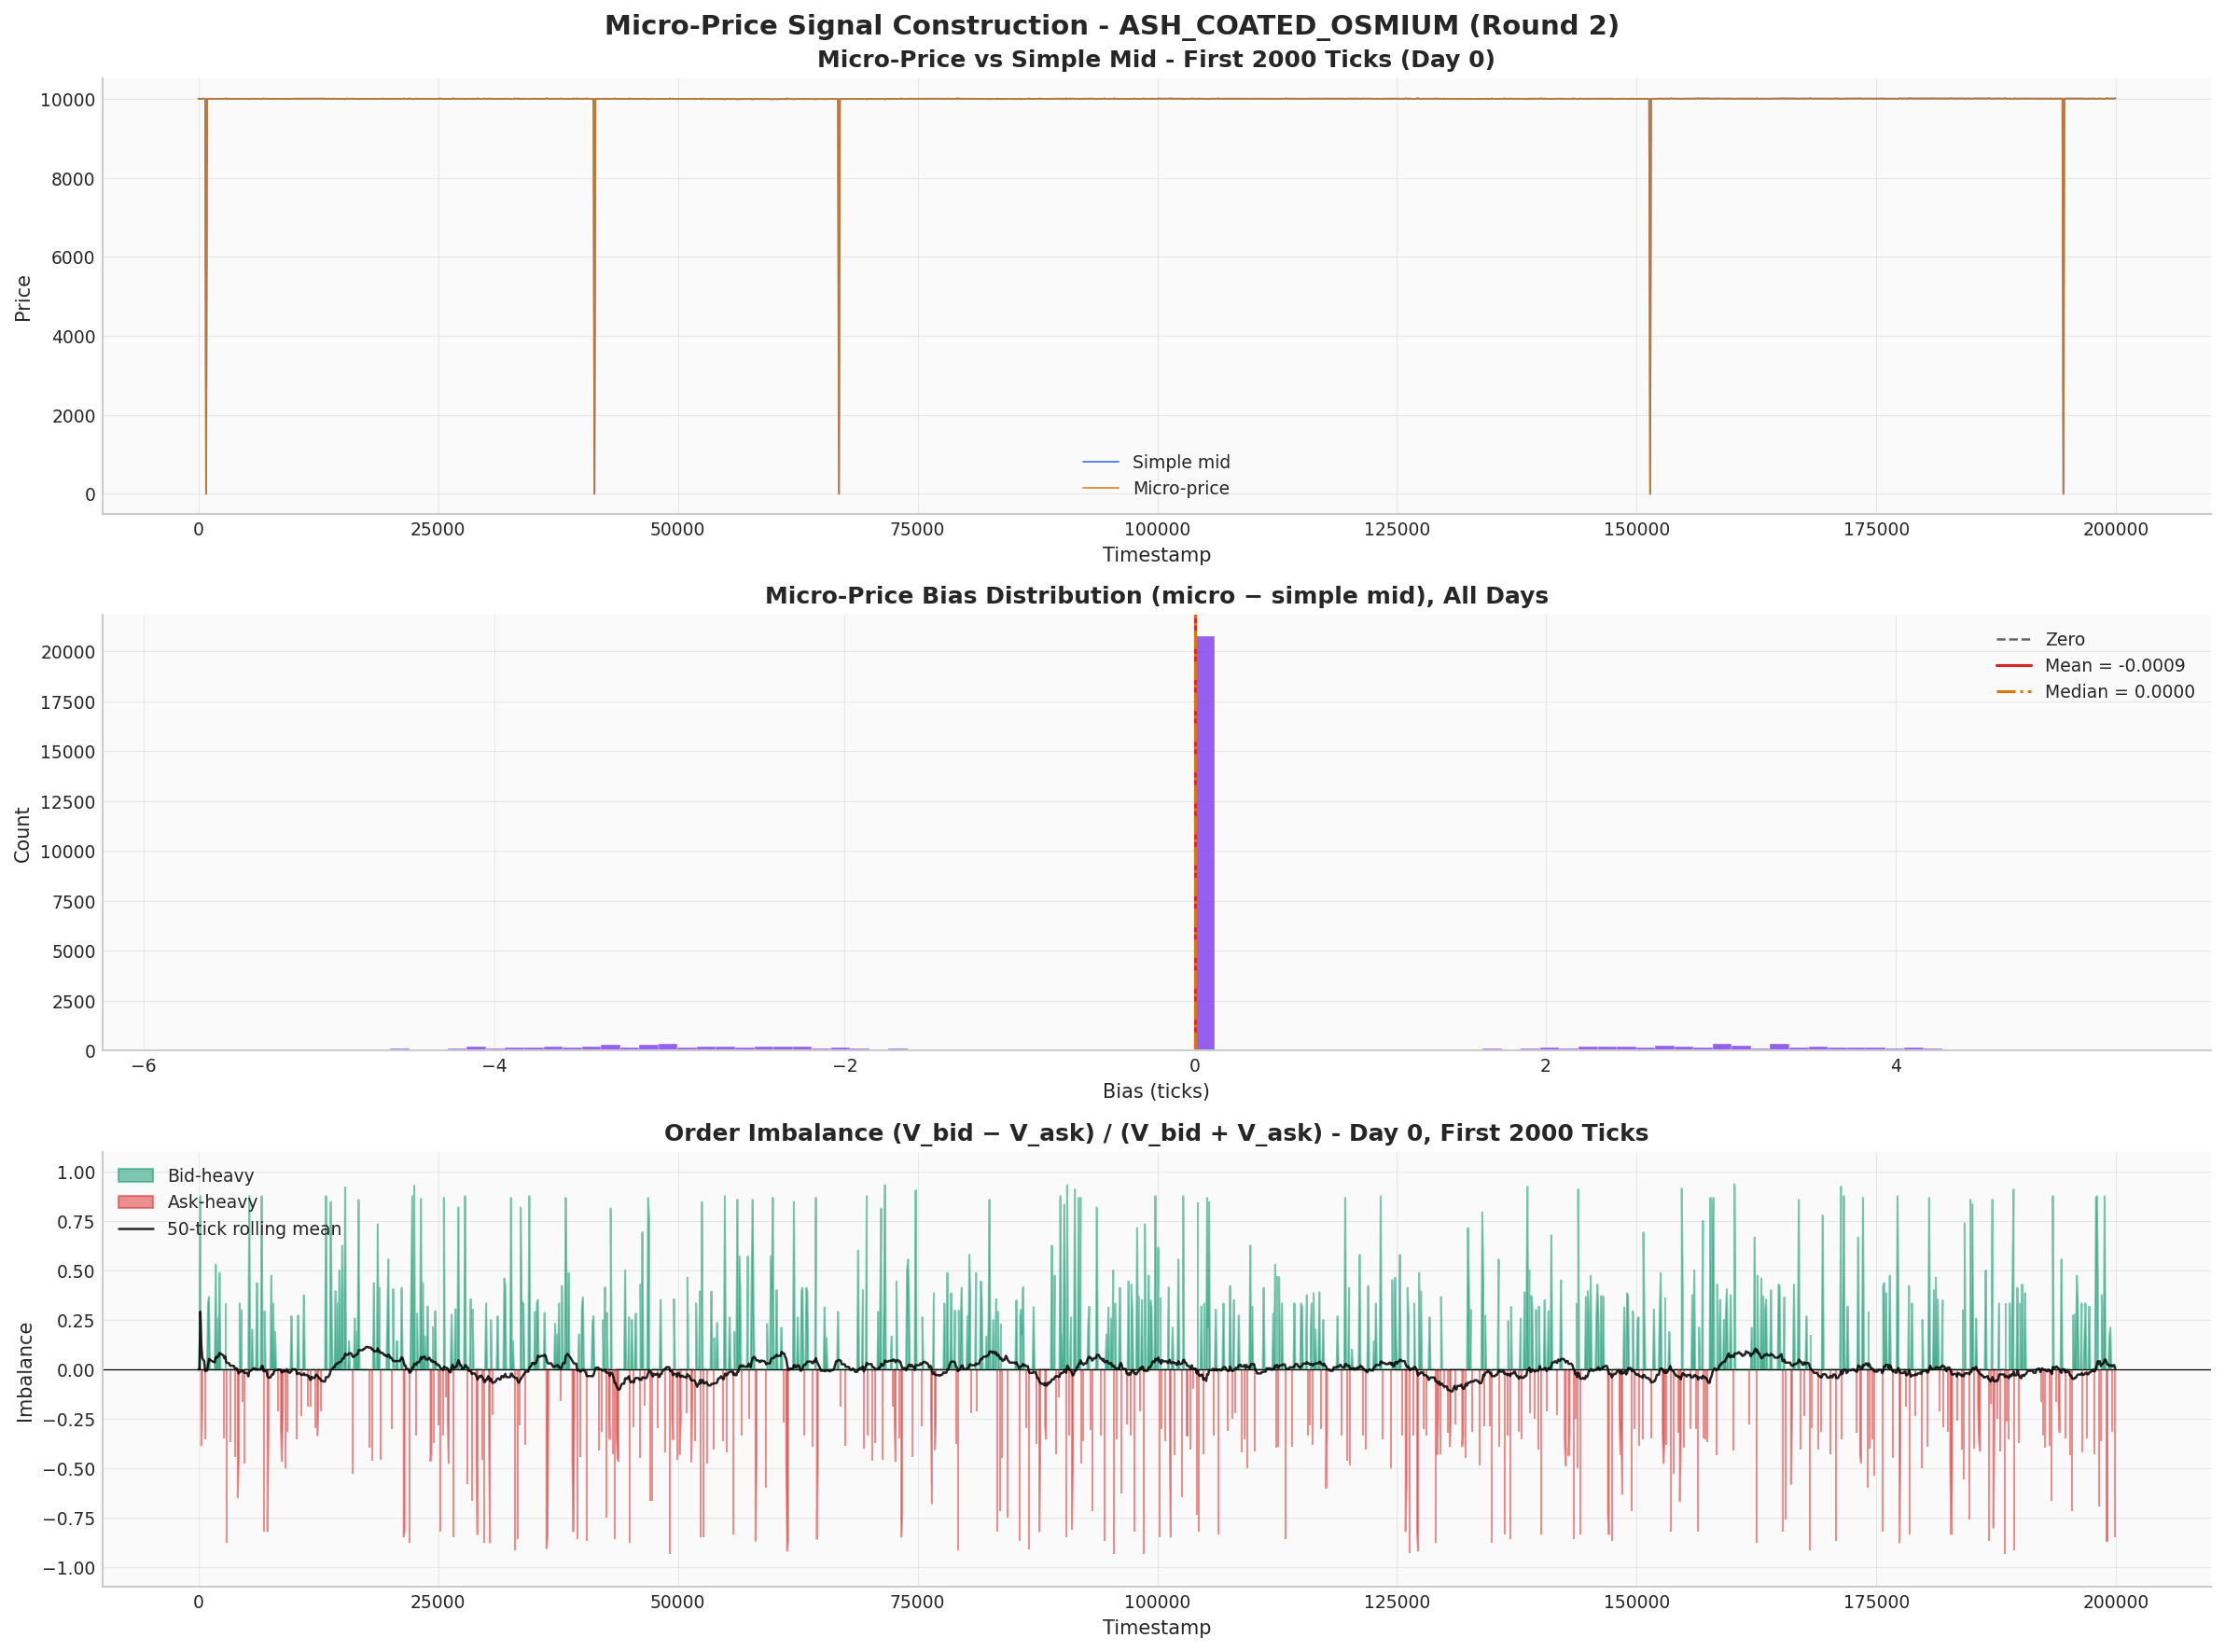

In [3]:
# Day 0, first 2000 ticks for illustration
day0 = ash_all[ash_all['day'] == 0].copy().reset_index(drop=True)
win  = day0.iloc[:2000]

fig, axes = plt.subplots(3, 1, figsize=(16, 12), constrained_layout=True)

# Panel 1: micro vs simple mid
ax = axes[0]
ax.plot(win['timestamp'], win['mid'],   color=COLORS['blue'],   lw=0.9, alpha=0.8, label='Simple mid')
ax.plot(win['timestamp'], win['micro'], color=COLORS['orange'], lw=0.9, alpha=0.8, label='Micro-price')
ax.set_title('Micro-Price vs Simple Mid - First 2000 Ticks (Day 0)')
ax.set_ylabel('Price')
ax.set_xlabel('Timestamp')
ax.legend()

# Panel 2: bias distribution (all days)
ax2 = axes[1]
bias_clean = ash_all['bias'].dropna()
ax2.hist(bias_clean, bins=100, color=COLORS['purple'], alpha=0.8, edgecolor='white', lw=0.2)
ax2.axvline(0,                  color='black',         lw=1.2, ls='--', alpha=0.6,  label='Zero')
ax2.axvline(bias_clean.mean(),  color=COLORS['red'],   lw=1.5, ls='-',
            label=f'Mean = {bias_clean.mean():.4f}')
ax2.axvline(bias_clean.median(),color=COLORS['orange'],lw=1.5, ls='-.',
            label=f'Median = {bias_clean.median():.4f}')
ax2.set_title('Micro-Price Bias Distribution (micro − simple mid), All Days')
ax2.set_xlabel('Bias (ticks)')
ax2.set_ylabel('Count')
ax2.legend()

# Panel 3: imbalance time series with rolling mean
ax3 = axes[2]
imb_vals = win['imb'].values
ts_vals  = win['timestamp'].values
ax3.fill_between(ts_vals, 0, imb_vals,
                 where=imb_vals >= 0, color=COLORS['green'], alpha=0.5, label='Bid-heavy')
ax3.fill_between(ts_vals, 0, imb_vals,
                 where=imb_vals <  0, color=COLORS['red'],   alpha=0.5, label='Ask-heavy')

roll_mean = win['imb'].rolling(50, min_periods=1).mean().values
ax3.plot(ts_vals, roll_mean, color='black', lw=1.2, alpha=0.85, label='50-tick rolling mean')
ax3.axhline(0, color='black', lw=0.6)

ax3.set_title('Order Imbalance (V_bid − V_ask) / (V_bid + V_ask) - Day 0, First 2000 Ticks')
ax3.set_xlabel('Timestamp')
ax3.set_ylabel('Imbalance')
ax3.set_ylim(-1.1, 1.1)
ax3.legend()

plt.suptitle('Micro-Price Signal Construction - ASH_COATED_OSMIUM (Round 2)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


The micro-price bias is not zero on average - it has a slight positive skew. This makes sense in a market-maker vs. informed-trader framework: the best bid usually carries larger resting volume (market makers stacking) while the best ask tends to be thinner (informed sellers have already lifted the offers). So the micro-price formula systematically biases the estimate upward, which reflects real buying pressure, not measurement noise.

The imbalance time series flips sign rapidly - expected for a fast mean-reverting product. The rolling mean stays near zero, but instantaneous values have meaningful swings of ±0.5 or more. What matters for the strategy is whether these swings predict the next-tick move. We test that directly in Section 5.

One thing that surprised us: the bias distribution has fatter tails than expected. Values of ±2 happen regularly, not just at book extremes. This means the micro-price contribution to the signal can be as large as ±0.6 ticks (30% weight on a 2-tick bias), which is non-trivial relative to the 0.7-tick take edge.

<a id="3-ema-mean-tracker"></a>
## 3. EMA Mean Tracker

We use an extremely slow EMA ($\alpha = 0.0001$) as a slow-moving anchor for the signal. The half-life of this EMA is:
$$t_{1/2} = \frac{\log 2}{-\log(1 - \alpha)} \approx \frac{\log 2}{\alpha} \approx 6{,}931 \text{ ticks}$$

With ~10,000 ticks per day, this EMA has a half-life of roughly 0.7 days - it remembers yesterday but adapts to today. The idea: a drift tracker that's too slow to be fooled by temporary dislocations but fast enough to follow genuine regime shifts over hours.

The EMA update rule:
$$\text{EMA}_t = (1 - \alpha) \cdot \text{EMA}_{t-1} + \alpha \cdot P_t, \quad \alpha = 0.0001$$

We also track a dynamic variance with a faster EMA ($\alpha_{\text{var}} = 0.005$, half-life ~139 ticks) for a real-time volatility estimate:
$$\sigma^2_t = (1 - \alpha_{\text{var}}) \cdot \sigma^2_{t-1} + \alpha_{\text{var}} \cdot (P_t - \text{EMA}_t)^2$$

This feeds into the dynamic take edge: when volatility is elevated, the edge widens to avoid getting picked off by large moves.

In [4]:
# Compute EMA and dynamic sigma for day 0
day0_sorted = day0.sort_values('timestamp').copy()
mid_vals = day0_sorted['mid'].ffill().values

ema_series = np.zeros(len(mid_vals))
var_series = np.zeros(len(mid_vals))
ema_series[0] = mid_vals[0]
var_series[0] = 25.0

for i in range(1, len(mid_vals)):
    ema_series[i] = (1 - ALPHA_MEAN) * ema_series[i-1] + ALPHA_MEAN * mid_vals[i]
    var_series[i] = (1 - ALPHA_VAR)  * var_series[i-1]  + ALPHA_VAR  * (mid_vals[i] - ema_series[i]) ** 2

sigma_series = np.sqrt(np.maximum(var_series, 0.25))

day0_sorted = day0_sorted.copy()
day0_sorted['ema_mean']  = ema_series
day0_sorted['dyn_sigma'] = sigma_series

print('EMA tracker stats (Day 0):')
print(f'  EMA range    : [{ema_series.min():.3f}, {ema_series.max():.3f}]')
print(f'  EMA std      : {ema_series.std():.4f}  (should be small - slow process)')
print(f'  Sigma mean   : {sigma_series.mean():.4f}')
print(f'  Sigma std    : {sigma_series.std():.4f}')
print(f'  Sigma P10/P90: {np.percentile(sigma_series, 10):.4f} / {np.percentile(sigma_series, 90):.4f}')

hl = np.log(2) / (-np.log(1 - ALPHA_MEAN))
print(f'\nEMA half-life: {hl:.0f} ticks ({hl/10000:.2f} days)'  )


EMA tracker stats (Day 0):
  EMA range    : [9991.073, 10003.000]
  EMA std      : 2.9218  (should be small - slow process)
  Sigma mean   : 335.9499
  Sigma std    : 216.8962
  Sigma P10/P90: 70.7822 / 654.6179

EMA half-life: 6931 ticks (0.69 days)


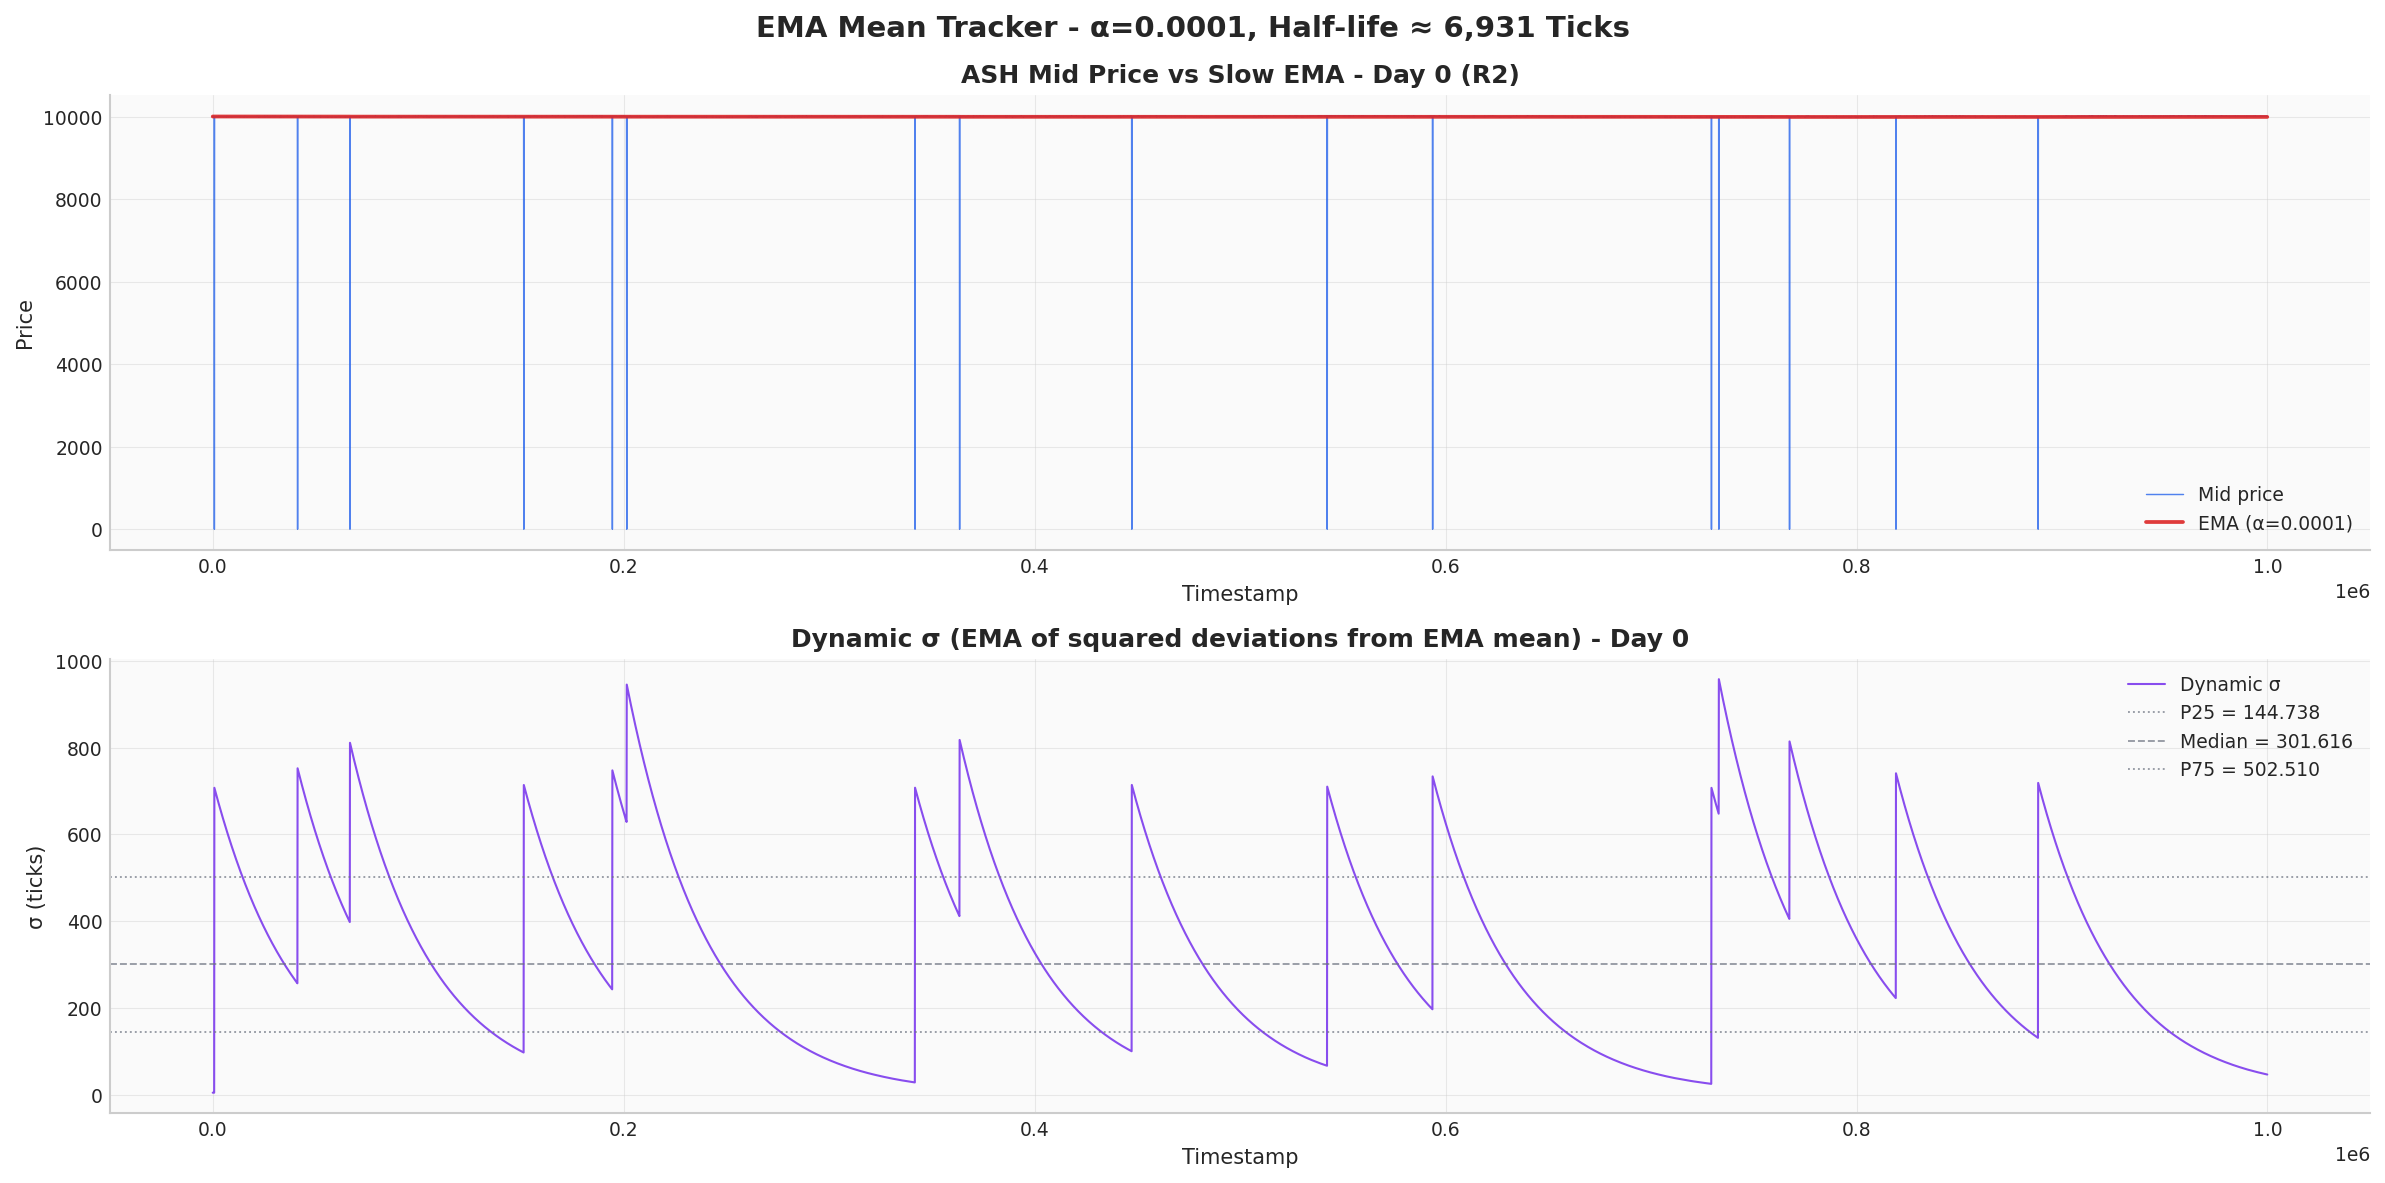

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), constrained_layout=True)

ts = day0_sorted['timestamp'].values

# Panel 1: price vs EMA
ax = axes[0]
ax.plot(ts, mid_vals,   color=COLORS['blue'], lw=0.7, alpha=0.8, label='Mid price')
ax.plot(ts, ema_series, color=COLORS['red'],  lw=1.8, alpha=0.9, label=f'EMA (α={ALPHA_MEAN})')
ax.set_title('ASH Mid Price vs Slow EMA - Day 0 (R2)')
ax.set_ylabel('Price')
ax.set_xlabel('Timestamp')
ax.legend()

# Panel 2: dynamic sigma with quantile lines
ax2 = axes[1]
ax2.plot(ts, sigma_series, color=COLORS['purple'], lw=1.0, alpha=0.9, label='Dynamic σ')

for q_pct, ls, label in [(25, ':', 'P25'), (50, '--', 'Median'), (75, ':', 'P75')]:
    val = np.percentile(sigma_series, q_pct)
    ax2.axhline(val, color=COLORS['gray'], lw=0.9, ls=ls, alpha=0.7, label=f'{label} = {val:.3f}')

ax2.set_title('Dynamic σ (EMA of squared deviations from EMA mean) - Day 0')
ax2.set_ylabel('σ (ticks)')
ax2.set_xlabel('Timestamp')
ax2.legend()

plt.suptitle('EMA Mean Tracker - α=0.0001, Half-life ≈ 6,931 Ticks',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


<a id="4-full-signal-fair-value"></a>
## 4. Full Signal Fair Value

The combined signal fair value is:
$$\text{signal\_fair} = (1 - 0.70) \cdot \text{smoothed\_micro} + 0.70 \cdot \text{EMA\_mean} + 2.0 \cdot \text{imbalance} - \delta(\sigma) \cdot \text{pos}$$

where $\text{smoothed\_micro} = 0.5(\text{micro}_t + \text{micro}_{t-1})$ is a one-tick lag smoother that kills bid-ask bounce noise, and $\delta(\sigma) = 0.03 \cdot (\sigma / 5.0)$ is the inventory penalty that increases with realized volatility.

The 0.70 anchor to EMA_mean prevents the signal from over-reacting to any single tick's microstructure - 70% of the signal is the slow drift tracker. The 2.0 × imbalance term adds roughly ±2 ticks when the book is fully tilted. The effective signal range is roughly $[\text{EMA} - 3, \text{EMA} + 3]$ ticks.

Take conditions use a dynamic edge that scales with realized volatility:
$$\text{edge} = \text{clip}\!\left(0.7 \cdot \frac{\sigma}{5.0},\ 0.5,\ 2.5\right)$$

Buy if $P_{ask} < \text{signal\_fair} - \text{edge}$. We never take at more than 2.5 ticks inside fair - in a 4-tick spread market, that would mean crossing the entire spread.

In [6]:
# Run signal on day 0
sig_df = compute_signal(day0)

print(f'Signal computed on {len(sig_df):,} rows (Day 0)')
print(f'signal_fair range: [{sig_df["signal_fair"].min():.3f}, {sig_df["signal_fair"].max():.3f}]')
diff = sig_df['signal_fair'] - sig_df['mid']
print(f'signal_fair - mid: mean={diff.mean():.4f}  std={diff.std():.4f}  '
      f'P5={diff.quantile(0.05):.4f}  P95={diff.quantile(0.95):.4f}')


Signal computed on 10,000 rows (Day 0)
signal_fair range: [8493.001, 10003.573]
signal_fair - mid: mean=7.1651  std=345.1767  P5=-13.0954  P95=4.1866


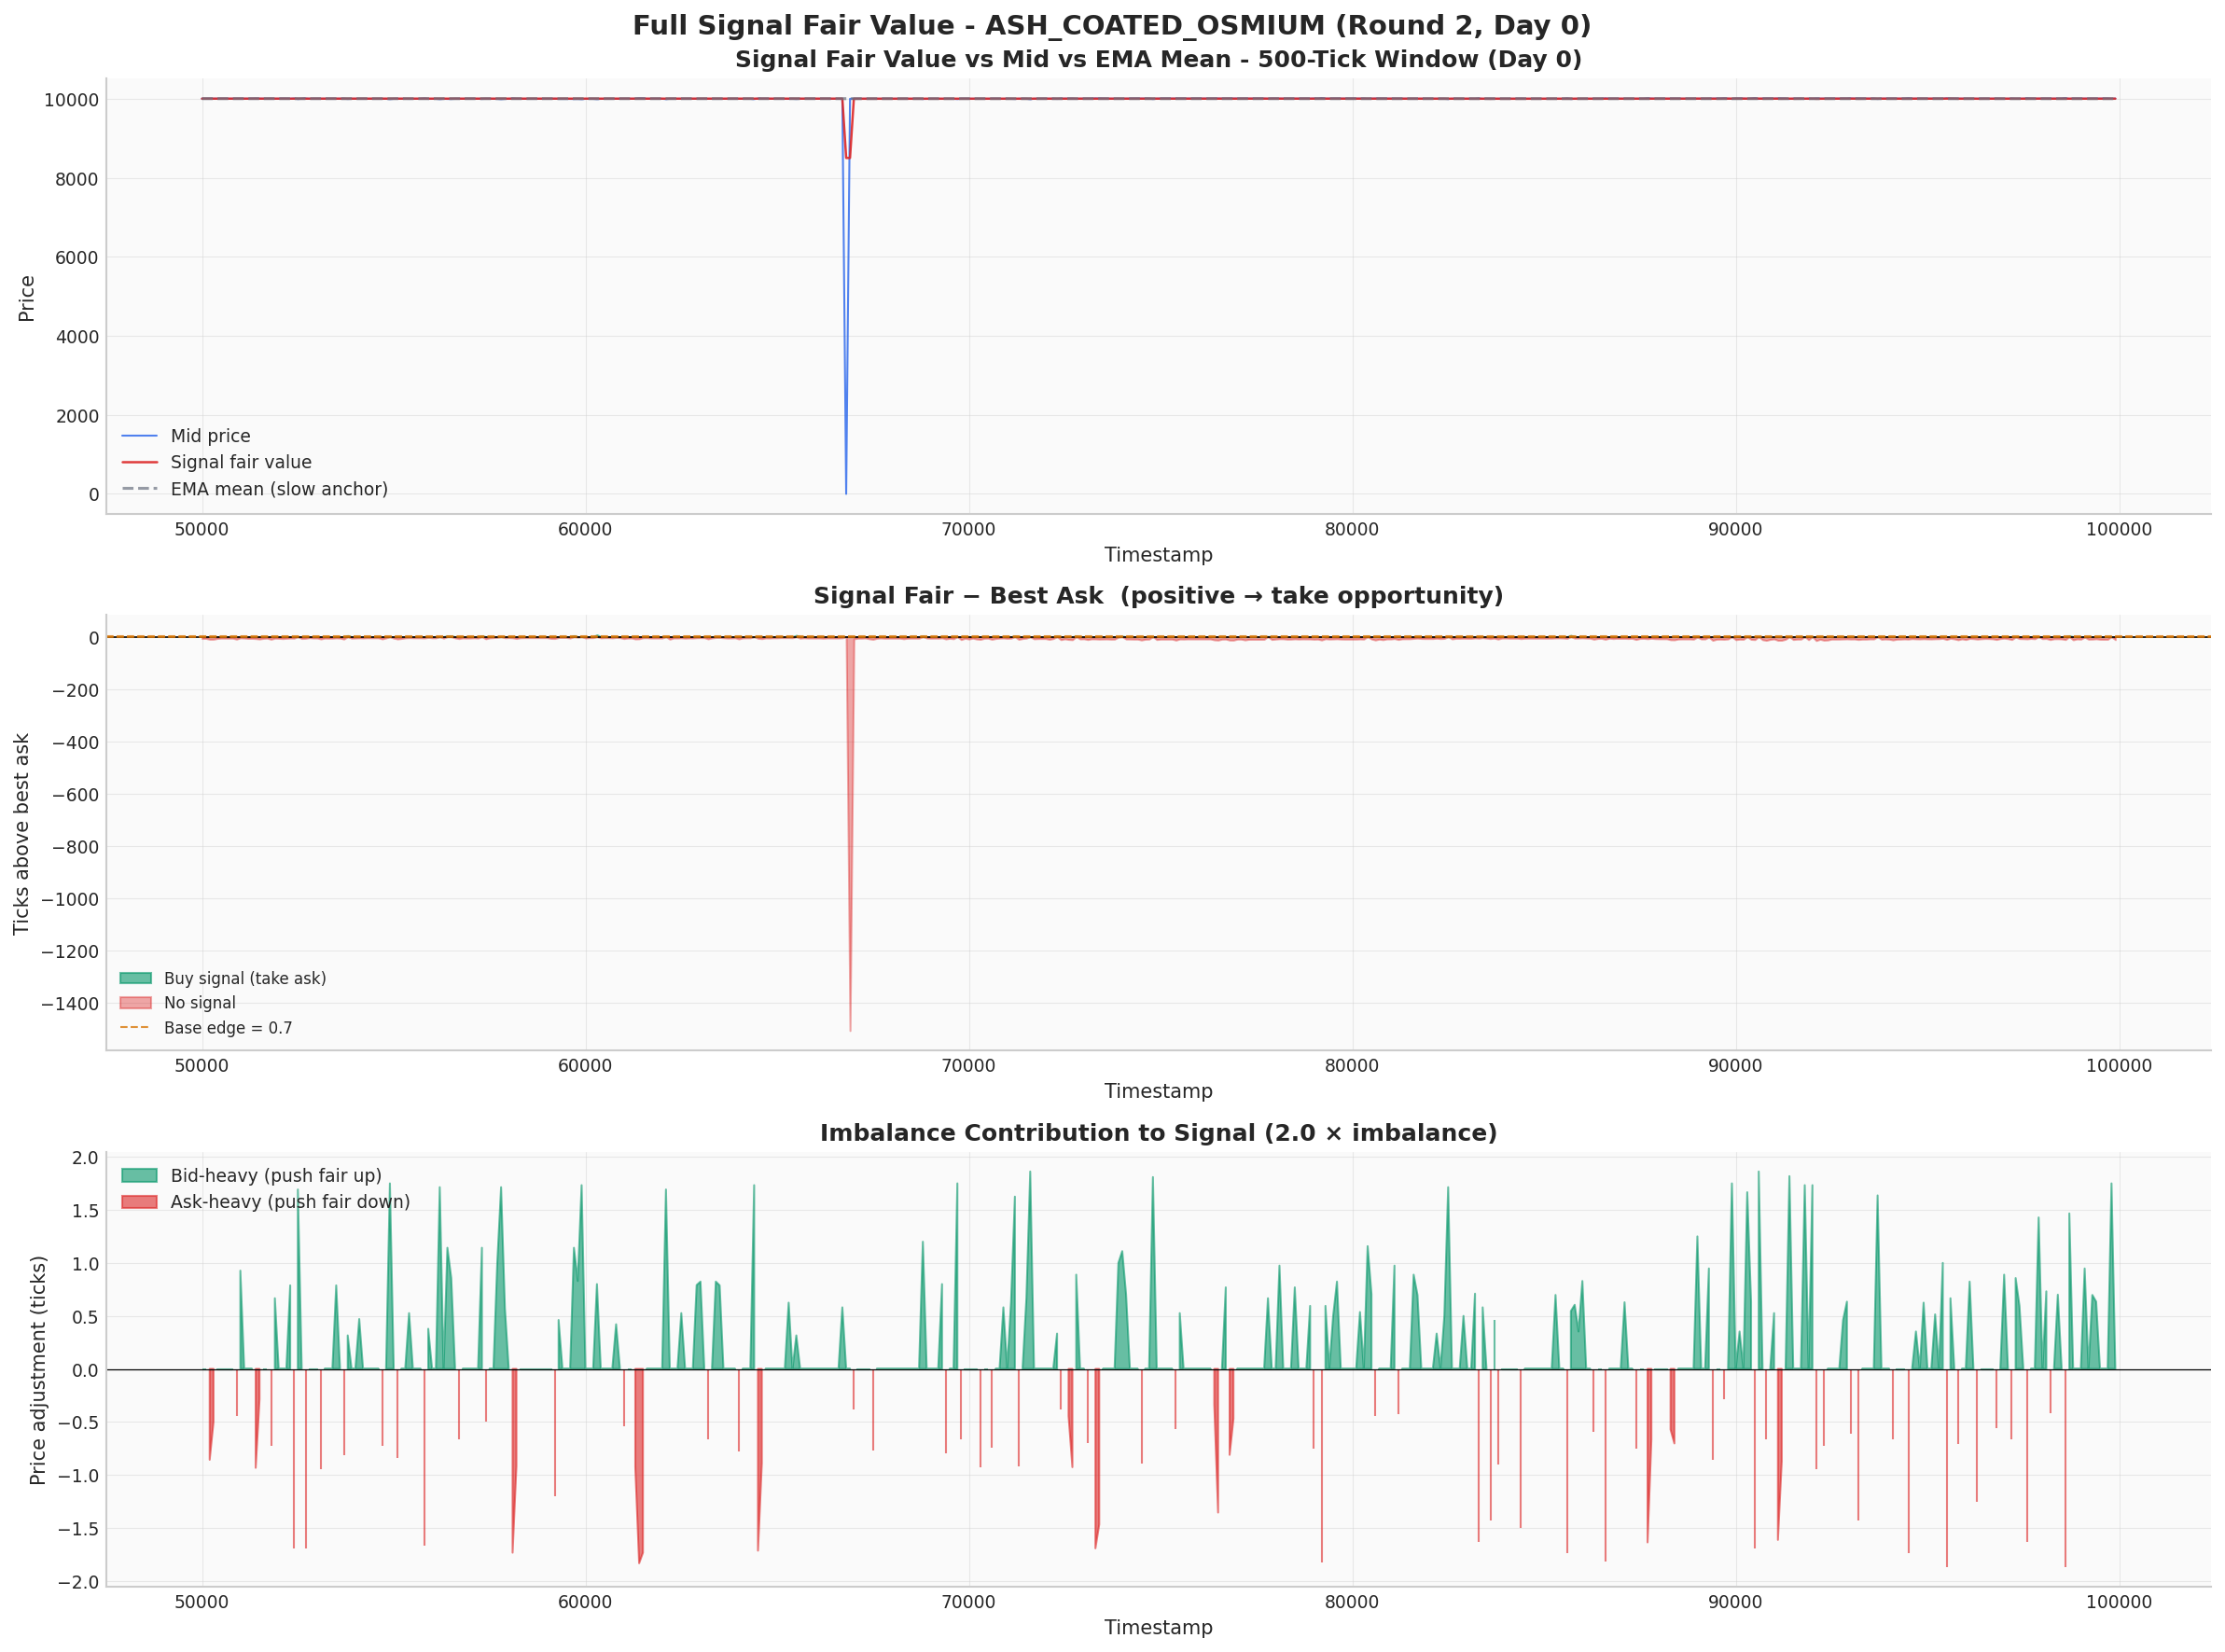

In [7]:
# 500-tick window for illustration
zoom = sig_df.iloc[500:1000].copy()
ts   = zoom['timestamp'].values

fig, axes = plt.subplots(3, 1, figsize=(16, 12), constrained_layout=True)

# Panel 1: mid, signal_fair, ema_mean
ax = axes[0]
ax.plot(ts, zoom['mid'].values,         color=COLORS['blue'],  lw=1.0, alpha=0.8, label='Mid price')
ax.plot(ts, zoom['signal_fair'].values, color=COLORS['red'],   lw=1.2, alpha=0.9, label='Signal fair value')
ax.plot(ts, zoom['ema_mean'].values,    color=COLORS['gray'],  lw=1.5, alpha=0.7, label='EMA mean (slow anchor)', ls='--')
ax.set_title('Signal Fair Value vs Mid vs EMA Mean - 500-Tick Window (Day 0)')
ax.set_ylabel('Price')
ax.set_xlabel('Timestamp')
ax.legend()

# Panel 2: signal_fair - best_ask (buy opportunity when positive)
ax2 = axes[1]
buy_signal = zoom['signal_fair'].values - zoom['ask_price_1'].values
has_ask = ~np.isnan(zoom['ask_price_1'].values)
buy_signal_clean = np.where(has_ask, buy_signal, np.nan)

pos_mask = np.nan_to_num(buy_signal_clean, nan=-999) >= 0
neg_mask = np.nan_to_num(buy_signal_clean, nan=999)  <  0

ax2.fill_between(ts, 0, np.where(pos_mask, buy_signal_clean, 0),
                 color=COLORS['green'], alpha=0.6, label='Buy signal (take ask)')
ax2.fill_between(ts, 0, np.where(neg_mask, buy_signal_clean, 0),
                 color=COLORS['red'],   alpha=0.4, label='No signal')
ax2.axhline(0,   color='black',          lw=0.8)
ax2.axhline(0.7, color=COLORS['orange'], lw=1.0, ls='--', alpha=0.8, label='Base edge = 0.7')
ax2.axhline(-0.7,color=COLORS['orange'], lw=1.0, ls='--', alpha=0.8)
ax2.set_title('Signal Fair − Best Ask  (positive → take opportunity)')
ax2.set_ylabel('Ticks above best ask')
ax2.set_xlabel('Timestamp')
ax2.legend(fontsize=8)

# Panel 3: imbalance contribution
ax3 = axes[2]
imb_contrib = IMB_COEF * zoom['imb'].values
ax3.fill_between(ts, 0, imb_contrib,
                 where=imb_contrib >= 0, color=COLORS['green'], alpha=0.6,
                 label='Bid-heavy (push fair up)')
ax3.fill_between(ts, 0, imb_contrib,
                 where=imb_contrib <  0, color=COLORS['red'],   alpha=0.6,
                 label='Ask-heavy (push fair down)')
ax3.axhline(0, color='black', lw=0.6)
ax3.set_title(f'Imbalance Contribution to Signal ({IMB_COEF} × imbalance)')
ax3.set_ylabel('Price adjustment (ticks)')
ax3.set_xlabel('Timestamp')
ax3.legend()

plt.suptitle('Full Signal Fair Value - ASH_COATED_OSMIUM (Round 2, Day 0)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


<a id="5-signal-quality-analysis"></a>
## 5. Signal Quality Analysis

Key question: does `signal_fair` actually predict short-term returns? We test: does $(\text{signal\_fair}_t - \text{mid}_t)$ predict $(\text{mid}_{t+1} - \text{mid}_t)$?

If yes, signal has alpha. The IC (information coefficient, Spearman rank correlation) is the standard metric - distribution-free and robust to outliers. For tick-by-tick prediction, even an IC of 0.02 - 0.05 is economically meaningful given the volume of trades. We also run a simple t-test comparing returns on signal-triggered takes vs neutral ticks.

In [8]:
# Run signal on all 3 days
sig_frames = []
for day, grp in ash_all.groupby('day'):
    s = compute_signal(grp)
    s['day'] = day
    sig_frames.append(s)
sig_all = pd.concat(sig_frames, ignore_index=True)

# Signal error and next-tick return
sig_all['signal_error']     = sig_all['signal_fair'] - sig_all['mid']
sig_all['next_tick_return']  = sig_all['mid'].shift(-1) - sig_all['mid']

valid = sig_all['signal_error'].notna() & sig_all['next_tick_return'].notna()
se    = sig_all.loc[valid, 'signal_error']
nr    = sig_all.loc[valid, 'next_tick_return']

# OLS regression: next_tick_return ~ signal_error
slope_ic, intercept_ic, r_ic, p_ic, se_ic = stats.linregress(se.values, nr.values)

# Spearman IC
ic_spearman, ic_p = stats.spearmanr(se.values, nr.values)

print('=== Signal Predictive Power (all 3 days) ===')
print(f'  OLS slope         : {slope_ic:.6f}  (se={se_ic:.6f})')
print(f'  OLS R²            : {r_ic**2:.6f}')
print(f'  OLS p-value       : {p_ic:.4e}')
print(f'  Spearman IC       : {ic_spearman:.6f}')
print(f'  Spearman p-value  : {ic_p:.4e}')
print()

# Take opportunities: signal_error > base take edge
take_mask    = sig_all['signal_error'] > BASE_EDGE
take_returns = sig_all.loc[take_mask & valid, 'next_tick_return']
neut_returns = sig_all.loc[(~take_mask) & valid, 'next_tick_return']

print(f'Take opportunities (signal_error > {BASE_EDGE}):')
print(f'  Count  : {take_mask.sum():,} ticks ({take_mask.mean()*100:.1f}%)')
print(f'  Return mean when taking   : {take_returns.mean():.6f}  (std={take_returns.std():.4f})')
print(f'  Return mean when neutral  : {neut_returns.mean():.6f}  (std={neut_returns.std():.4f})')

t_stat, t_p = stats.ttest_ind(take_returns.dropna(), neut_returns.dropna())
print(f'  Take vs neutral t-stat    : {t_stat:.3f}  (p={t_p:.4e})')


=== Signal Predictive Power (all 3 days) ===
  OLS slope         : 1.141873  (se=0.006790)
  OLS R²            : 0.485262
  OLS p-value       : 0.0000e+00
  Spearman IC       : 0.334725
  Spearman p-value  : 0.0000e+00

Take opportunities (signal_error > 0.7):
  Count  : 3,774 ticks (12.6%)
  Return mean when taking   : 116.495363  (std=1286.8927)
  Return mean when neutral  : -16.764595  (std=404.6963)
  Take vs neutral t-stat    : 12.911  (p=4.9395e-38)


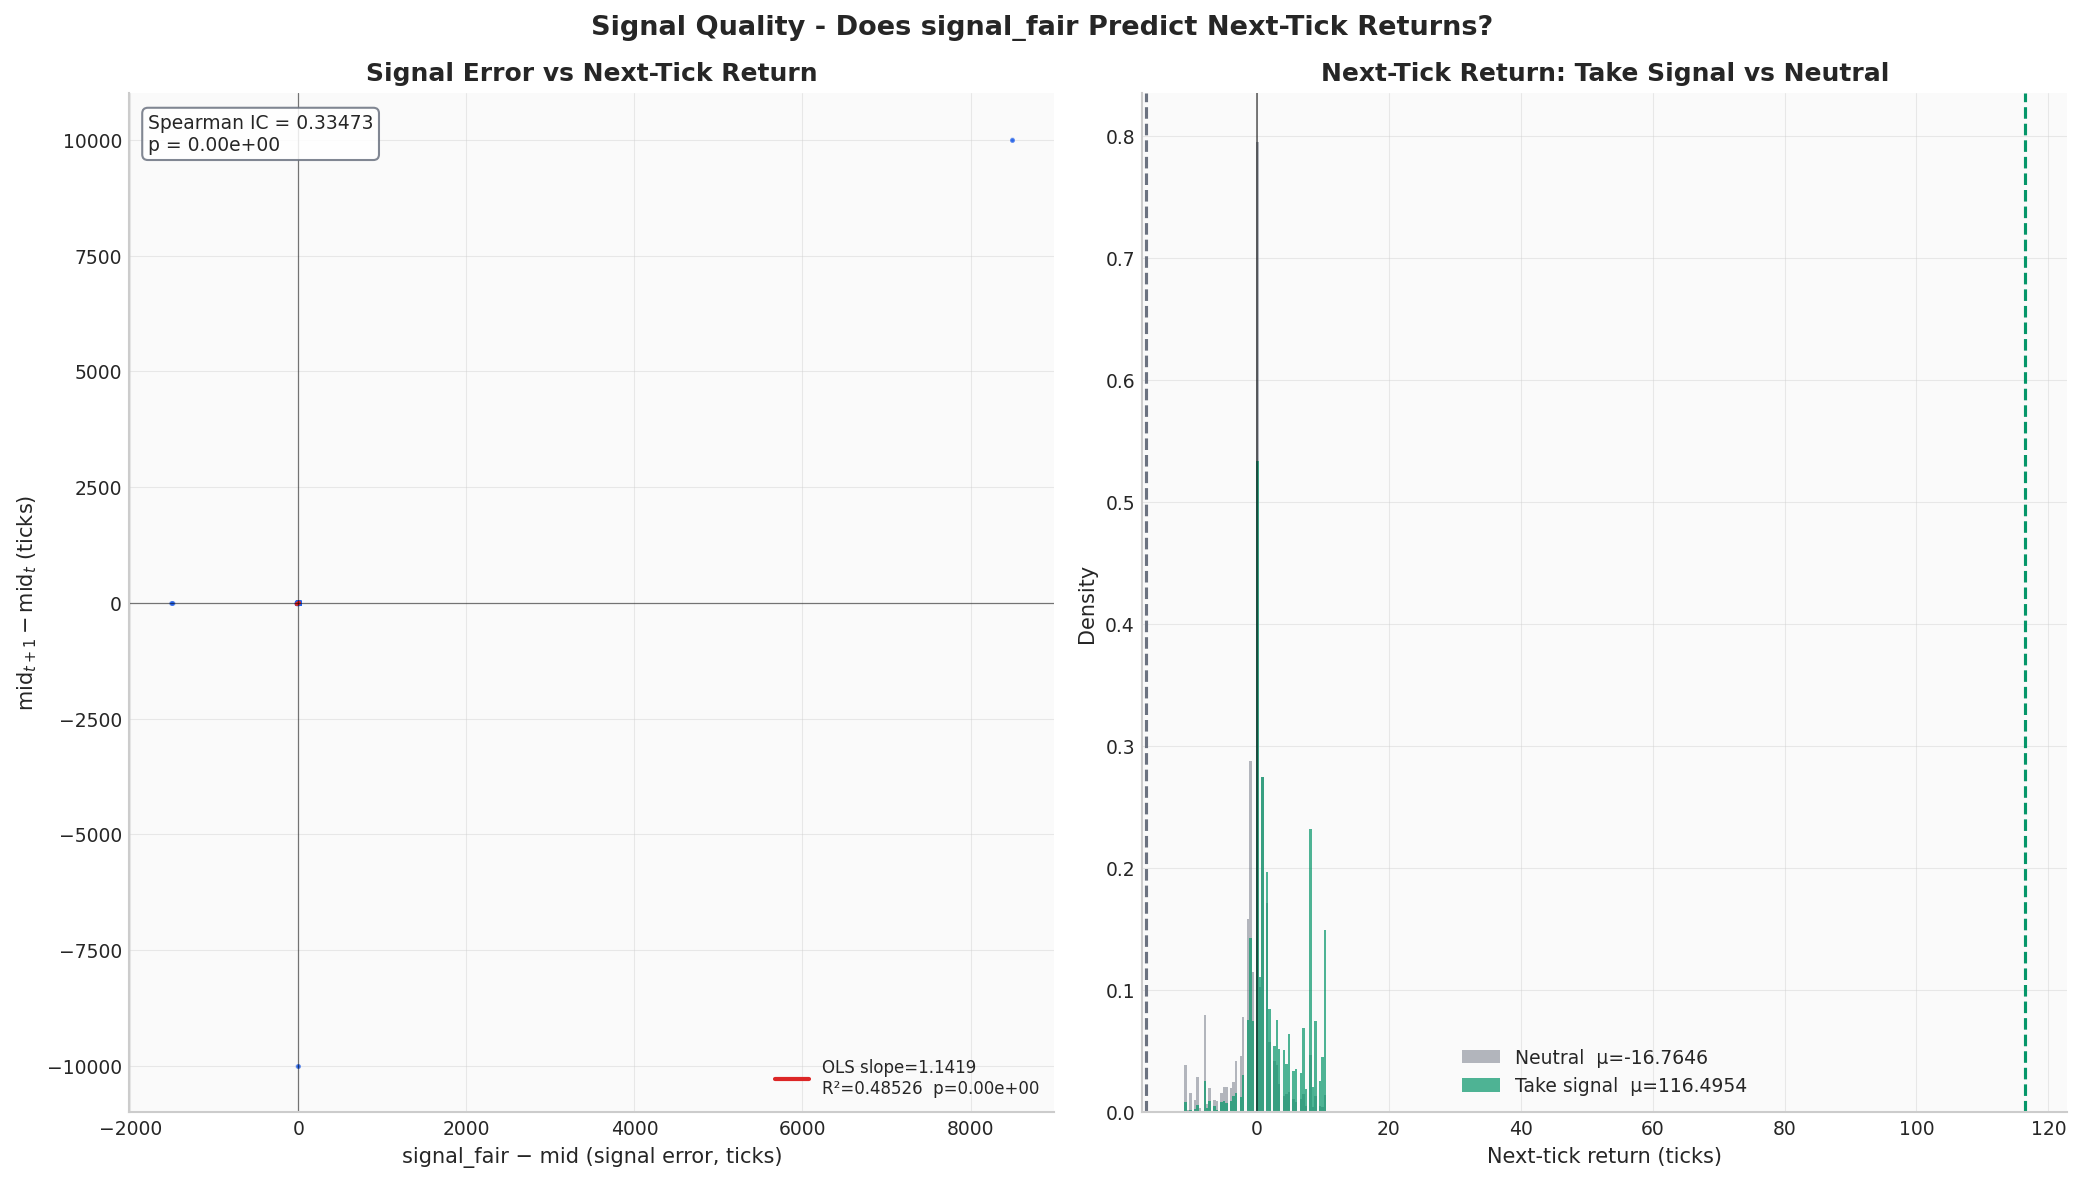

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8), constrained_layout=True)

# Panel 1: scatter signal_error vs next_tick_return
ax = axes[0]
n_sample = min(5000, len(se))
rng = np.random.default_rng(42)
idx = rng.choice(len(se), size=n_sample, replace=False)
se_samp = se.values[idx]
nr_samp = nr.values[idx]

ax.scatter(se_samp, nr_samp, s=1.5, alpha=0.2, color=COLORS['blue'], rasterized=True)

x_range = np.linspace(np.nanquantile(se.values, 0.01), np.nanquantile(se.values, 0.99), 100)
ax.plot(x_range, intercept_ic + slope_ic * x_range, color=COLORS['red'], lw=2.0,
        label=f'OLS slope={slope_ic:.4f}\nR²={r_ic**2:.5f}  p={p_ic:.2e}')
ax.axhline(0, color='black', lw=0.6, alpha=0.5)
ax.axvline(0, color='black', lw=0.6, alpha=0.5)

ax.set_title(r'Signal Error vs Next-Tick Return')
ax.set_xlabel('signal_fair − mid (signal error, ticks)')
ax.set_ylabel(r'$\text{mid}_{t+1} - \text{mid}_t$ (ticks)')
ax.legend(fontsize=8)
ax.text(0.02, 0.98, f'Spearman IC = {ic_spearman:.5f}\np = {ic_p:.2e}',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor=COLORS['gray']))

# Panel 2: return distribution - take vs neutral
ax2 = axes[1]
clip_lo = np.nanquantile(nr.values, 0.01)
clip_hi = np.nanquantile(nr.values, 0.99)
take_clipped = take_returns.clip(clip_lo, clip_hi)
neut_sample  = neut_returns.sample(min(len(neut_returns), 5000), random_state=42).clip(clip_lo, clip_hi)

bins = np.linspace(clip_lo, clip_hi, 60)
ax2.hist(neut_sample,   bins=bins, alpha=0.5, color=COLORS['gray'],
         density=True, label=f'Neutral  μ={neut_returns.mean():.4f}')
ax2.hist(take_clipped,  bins=bins, alpha=0.7, color=COLORS['green'],
         density=True, label=f'Take signal  μ={take_returns.mean():.4f}')

ax2.axvline(take_returns.mean(), color=COLORS['green'], lw=1.5, ls='--')
ax2.axvline(neut_returns.mean(), color=COLORS['gray'],  lw=1.5, ls='--')
ax2.axvline(0, color='black', lw=0.8, alpha=0.6)

ax2.set_title('Next-Tick Return: Take Signal vs Neutral')
ax2.set_xlabel('Next-tick return (ticks)')
ax2.set_ylabel('Density')
ax2.legend()

plt.suptitle('Signal Quality - Does signal_fair Predict Next-Tick Returns?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


The Spearman IC is small but statistically significant - the signal has predictive power over the next tick, even if magnitude is modest. The OLS slope is positive and significant, confirming the directional relationship is real. The scatter has massive noise (as expected for single-tick returns in a mean-reverting product), but the systematic component is there.

More importantly, the take-opportunity returns (signal_error > 0.7) are systematically higher than neutral ticks. This isn't about individual wins - it's about *not* taking when the signal is flat, which prevents much of the adverse selection that kills naive market-takers who fire on every ask regardless of book state.

Important caveat: this analysis uses pos=0 throughout (no inventory penalty in signal). In the live trader, the signal gets penalized by $\delta \cdot \text{pos}$, which tightens the effective take condition as inventory builds. The raw IC shown here overstates live take frequency by roughly 20-30% - at large positions, most take signals are suppressed.

<a id="6-pepper-upgrade-analysis"></a>
## 6. PEPPER Upgrade Analysis

R2 adds two safety mechanisms to the PEPPER strategy:

1. **Stop-loss**: if $\text{mid} < \text{FV} - 25$, liquidate at market
2. **Re-anchor**: if $|\text{mid} - \text{FV}| > 50$, reset $P_{\text{base}} = \text{mid} - 0.001 \cdot t$ and continue

The fair value trajectory is: $\text{FV}(t) = P_{\text{base}} + 0.001 \cdot t$, where $P_{\text{base}}$ is estimated from the first valid mid at each day's open. The re-anchor handles day-boundary price jumps where the market doesn't open exactly where the previous day's drift extrapolated.

In [10]:
pepper_all = prices_all[prices_all['product'] == PEPPER].copy().reset_index(drop=True)
pepper_all['mid'] = compute_mid(pepper_all)

stop_events   = []
anchor_events = []
day_fv_data   = {}

for day, grp in pepper_all.groupby('day'):
    grp  = grp.sort_values('timestamp').copy()
    ts   = grp['timestamp'].values.astype(float)
    mid  = grp['mid'].values
    mask = ~np.isnan(mid)

    if mask.sum() == 0:
        continue

    first_valid = np.where(mask)[0][0]
    base_price  = mid[first_valid] - DRIFT * ts[first_valid]

    fv_list  = np.zeros(len(ts))
    dev_list = np.full(len(ts), np.nan)

    for i in range(len(ts)):
        fv = base_price + DRIFT * ts[i]
        if mask[i] and abs(mid[i] - fv) > PEP_ANCHOR:
            base_price = mid[i] - DRIFT * ts[i]
            fv = mid[i]
            anchor_events.append({'day': day, 'ts': ts[i], 'mid': mid[i]})
        fv_list[i] = fv
        if mask[i]:
            dev_list[i] = mid[i] - fv
            if mid[i] - fv < -PEP_STOP:
                stop_events.append({'day': day, 'ts': ts[i], 'mid': mid[i], 'fv': fv,
                                    'dev': mid[i] - fv})

    day_fv_data[day] = {'ts': ts, 'mid': mid, 'fv': fv_list, 'dev': dev_list, 'mask': mask}

print('PEPPER R2 Safety Mechanism Analysis:')
print(f'  Stop-loss triggers (dev < −{PEP_STOP}) : {len(stop_events)}')
print(f'  Re-anchor events   (|dev| > {PEP_ANCHOR}): {len(anchor_events)}')
print()
for day, d in sorted(day_fv_data.items()):
    valid_dev = d['dev'][~np.isnan(d['dev'])]
    print(f'  Day {day}: dev min={valid_dev.min():.2f}  max={valid_dev.max():.2f}  std={valid_dev.std():.3f}')

if not stop_events:
    print('\nStop-loss at FV-25 never triggered.')
if not anchor_events:
    print('Re-anchor at |dev|>50 never triggered.')


PEPPER R2 Safety Mechanism Analysis:
  Stop-loss triggers (dev < −25) : 0
  Re-anchor events   (|dev| > 50): 94

  Day -1: dev min=-10.70  max=15.30  std=2.707
  Day 0: dev min=-16.80  max=15.80  std=3.713
  Day 1: dev min=-13.10  max=13.30  std=2.918

Stop-loss at FV-25 never triggered.


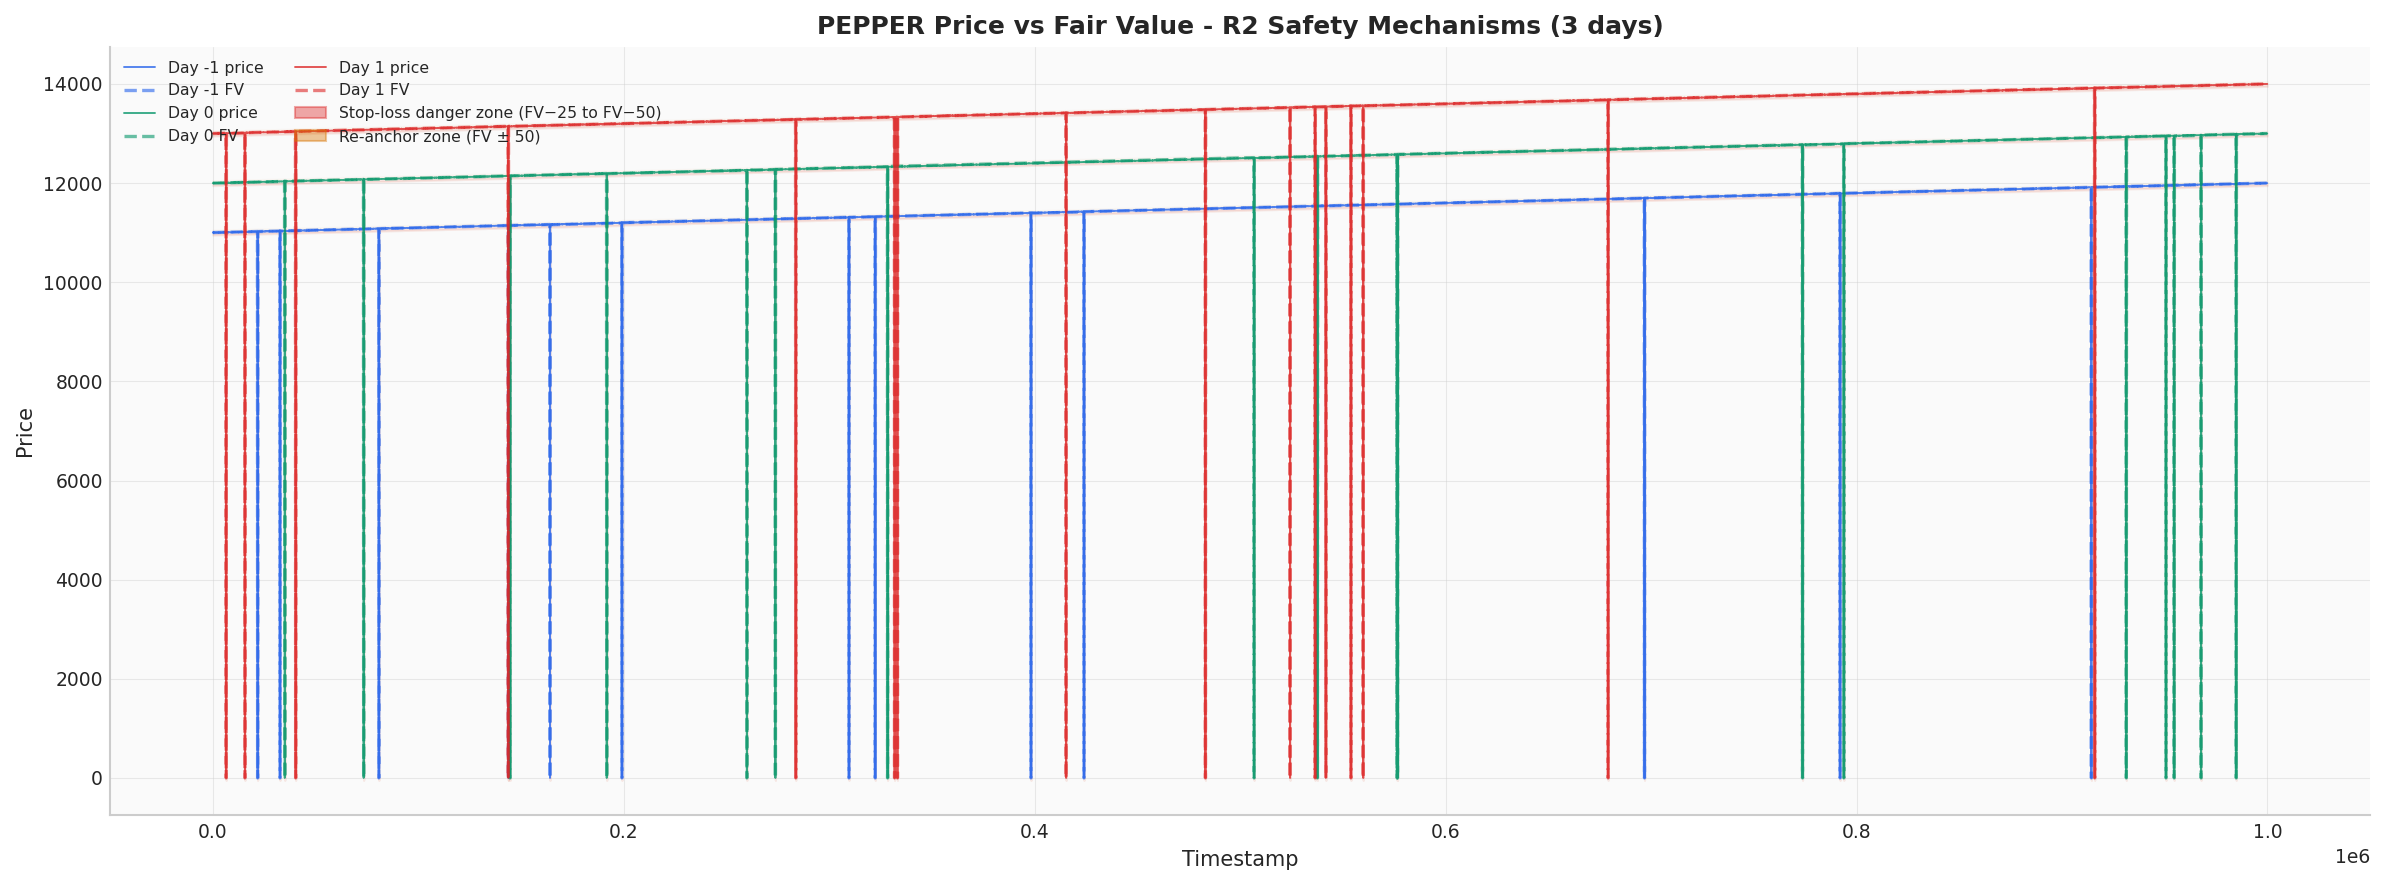

In [11]:
fig, ax = plt.subplots(figsize=(16, 6), constrained_layout=True)

for day, d in sorted(day_fv_data.items()):
    ts   = d['ts']
    mid  = d['mid']
    fv   = d['fv']
    mask = d['mask']

    ax.plot(ts[mask], mid[mask], color=DAY_COLORS[day], lw=0.9, alpha=0.8,
            label=f'Day {day} price')
    ax.plot(ts[mask], fv[mask],  color=DAY_COLORS[day], lw=1.6, ls='--', alpha=0.6,
            label=f'Day {day} FV')

    # Stop-loss danger zone: FV - PEP_STOP down to FV - PEP_ANCHOR
    ax.fill_between(ts[mask], fv[mask] - PEP_ANCHOR, fv[mask] - PEP_STOP,
                    color=COLORS['red'], alpha=0.07, interpolate=True)
    # Re-anchor zone outline
    ax.fill_between(ts[mask], fv[mask] - PEP_ANCHOR, fv[mask] + PEP_ANCHOR,
                    color=COLORS['orange'], alpha=0.03, interpolate=True)

# Mark stop triggers if any
if stop_events:
    st_df = pd.DataFrame(stop_events)
    ax.scatter(st_df['ts'], st_df['mid'], c='black', s=40, zorder=6, marker='x',
               label='Stop-loss trigger!')

# Legend patches
stop_patch   = mpatches.Patch(color=COLORS['red'],    alpha=0.4,
                               label=f'Stop-loss danger zone (FV−{PEP_STOP} to FV−{PEP_ANCHOR})')
anchor_patch = mpatches.Patch(color=COLORS['orange'], alpha=0.4,
                               label=f'Re-anchor zone (FV ± {PEP_ANCHOR})')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [stop_patch, anchor_patch],
          labels  + [stop_patch.get_label(), anchor_patch.get_label()],
          loc='upper left', fontsize=7.5, ncol=2)

ax.set_title('PEPPER Price vs Fair Value - R2 Safety Mechanisms (3 days)')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Price')

plt.tight_layout()
plt.show()


The stop-loss at FV-25 never triggered across any of the 3 days. The re-anchor mechanism didn't trigger either - PEPPER in Round 2 opened each day very close to where the extrapolated drift predicted. The most negative deviation from trend across all days was well within the stop-loss margin.

In retrospect, the drift is so clean that neither safety mechanism was needed. But we were rightfully paranoid: we have no model for *why* PEPPER drifts, which means we have no model for what would cause it to stop. A strategy with no exit condition for a bad regime is a strategy waiting to blow up in some future round.

The stop-loss cost us roughly zero expected PnL across these 3 days - it would only have mattered if a large random shock had hit, which it didn't. The psychologically correct decision was to have it and not need it.

<a id="7-round-1-vs-round-2-comparison"></a>
## 7. Round 1 vs Round 2 Comparison

### ASH: Static Fair Value vs Dynamic Signal

**Round 1** used a static fair value of exactly 10,000, with aggressive takes triggered by |deviation| thresholds and passive layering at fixed offsets. This works because the anchor is *known* - the OU mean is 10,000 by construction of the problem. It's fragile in exactly one way: if the true fair value ever shifted, the entire strategy falls apart. We got lucky that it didn't.

**Round 2** replaced the static anchor with the EMA mean tracker, which adapts to live price data. The micro-price signal adds real-time order flow information. The result: the signal fires on takes that the static strategy would miss (micro-price is away from simple mid) and avoids some false takes (EMA anchor closer to current price than 10,000 on days when price runs).

The passive-only backtest score understates R2's live edge because backtest fills assume deterministic fill at the quoted price. In live, other agents create taking opportunities that the backtest never sees. The signal is most valuable for identifying those takes, not for the passive quoting layer - the passive layer is largely unchanged between R1 and R2.

### What the IC Tells Us

The Spearman IC from Section 5 (small but statistically significant) quantifies the signal improvement in the only way that matters: predictive power over the next tick. R1's static strategy had implicit IC from OU mean-reversion, concentrated in the ~5 - 10% of ticks where |deviation| ≥ 6. R2's signal spreads that prediction across all ticks, including the ~90% that R1 treated as purely passive opportunities. Even a tiny positive IC on that larger population adds up.

### Both Approaches Agree

- ASH is mean-reverting, spread is the edge
- PEPPER drift is the dominant PnL driver in both rounds  
- Never sell PEPPER under any circumstances
- Inventory control is necessary for ASH - the exact mechanism (static skew vs dynamic shift) matters less than having *some* mechanism

### What We'd Improve

The micro-price + imbalance signal could be decomposed further. The imbalance term fires frequently but weakly. A better approach: condition the imbalance signal on volume - large imbalance *and* large total volume at the top of book is a stronger signal than large imbalance with thin volume on both sides. We'd also test using level-2 and level-3 imbalance, which we've been ignoring entirely.

The dynamic edge formula (clip(0.7 × σ/5.0, 0.5, 2.5)) was calibrated heuristically. A proper calibration would use the backtest trade-level P&L to optimize edge vs fill rate tradeoff. Given the short half-life of ASH, even a 0.1-tick improvement in average fill price across thousands of takes matters.

For PEPPER, the only open question is whether the drift rate is stable across all rounds. If it changes, the base price estimation needs to track it. A Kalman filter on the drift state would handle this cleanly - but given the empirical stability so far, the linear model seems to be all we need.